<a href="https://colab.research.google.com/github/rah-ds/Cloud-Autoscaling-using-RL/blob/bmcgregor%2Fsimulator-refactor/Experiment_DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Experiment 1 - DQN

In [ ]:

raw_url = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py'

# Replace with the desired local filename for your script
local_filename = 'autoscaling_env.py'

!wget -O {local_filename} {raw_url}

--2025-11-23 20:52:37--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8232 (8.0K) [text/plain]
Saving to: ‘autoscaling_env.py’

autoscaling_env.py  100%[===================>]   8.04K  --.-KB/s    in 0s      

2025-11-23 20:52:37 (105 MB/s) - ‘autoscaling_env.py’ saved [8232/8232]



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df_usage = pd.read_csv('/content/drive/MyDrive/df_usage.csv')
display(df_usage.head())

,time_window,avg_cpu,avg_mem,active_machines
0,1970-01-01 00:05:00+00:00,0.006623,0.004912,9525
1,1970-01-01 00:06:00+00:00,0.003254,0.002733,3805
2,1970-01-01 00:07:00+00:00,0.003070,0.002770,4167
3,1970-01-01 00:08:00+00:00,0.001950,0.001823,4338
4,1970-01-01 00:09:00+00:00,0.001689,0.001468,5545


In [ ]:
from autoscaling_env import AutoScalingEnv
env = AutoScalingEnv(df_usage) # Then you can use it

In [ ]:
print('Resetting the environment...')
initial_state, initial_info = env.reset()
print(f'Initial State: {initial_state}')
print(f'Initial Info: {initial_info}')

import random
action = random.randint(0, env.action_space.n - 1)
print(f'Taking random action: {action}')

next_state, reward, terminated, truncated, info = env.step(action)

print(f'\nAfter one step:')
print(f'Next State: {next_state}')
print(f'Reward: {reward}')
print(f'Terminated: {terminated}')
print(f'Truncated: {truncated}')
print(f'Info: {info}')

Resetting the environment...
Initial State: [6.6225836e-03 4.9124165e-03 1.0000000e+01]
Initial Info: {'initial_capacity': 10}
Taking random action: 1

After one step:
Next State: [3.2542923e-03 2.7331815e-03 1.0000000e+01]
Reward: -60.80811775319542
Terminated: False
Truncated: False
Info: {'current_capacity': 10, 'utilization': np.float64(6.308010704835946), 'estimated_total_cpu_load': np.float64(63.080107048359466), 'reward_components': {'cost_penalty': -0.02, 'sla_penalty': np.float64(-55.080107048359466), 'util_deviation_penalty': np.float64(-5.708010704835947)}}


## DQN Experiment Section



Episode 10	Average Score: -40198.75
Episode 20	Average Score: -9004.94
Episode 30	Average Score: -11152.61
Episode 40	Average Score: -5747.29
Episode 50	Average Score: -4757.76
Episode 60	Average Score: -4669.94
Episode 70	Average Score: -3876.43
Episode 80	Average Score: -3247.15
Episode 90	Average Score: -3308.79
Episode 100	Average Score: -2965.38
Episode 110	Average Score: -2824.66
Episode 120	Average Score: -2771.90
Episode 130	Average Score: -2607.44
Episode 140	Average Score: -2712.24
Episode 150	Average Score: -2431.64
Episode 160	Average Score: -2456.49
Episode 170	Average Score: -2345.11
Episode 180	Average Score: -2379.14
Episode 190	Average Score: -2224.65
Episode 200	Average Score: -2329.31
Episode 210	Average Score: -2164.29
Episode 220	Average Score: -2135.03
Episode 230	Average Score: -2147.68
Episode 240	Average Score: -2163.84
Episode 250	Average Score: -2100.22
Episode 260	Average Score: -2119.61
Episode 270	Average Score: -2080.32
Episode 280	Average Score: -2042.89

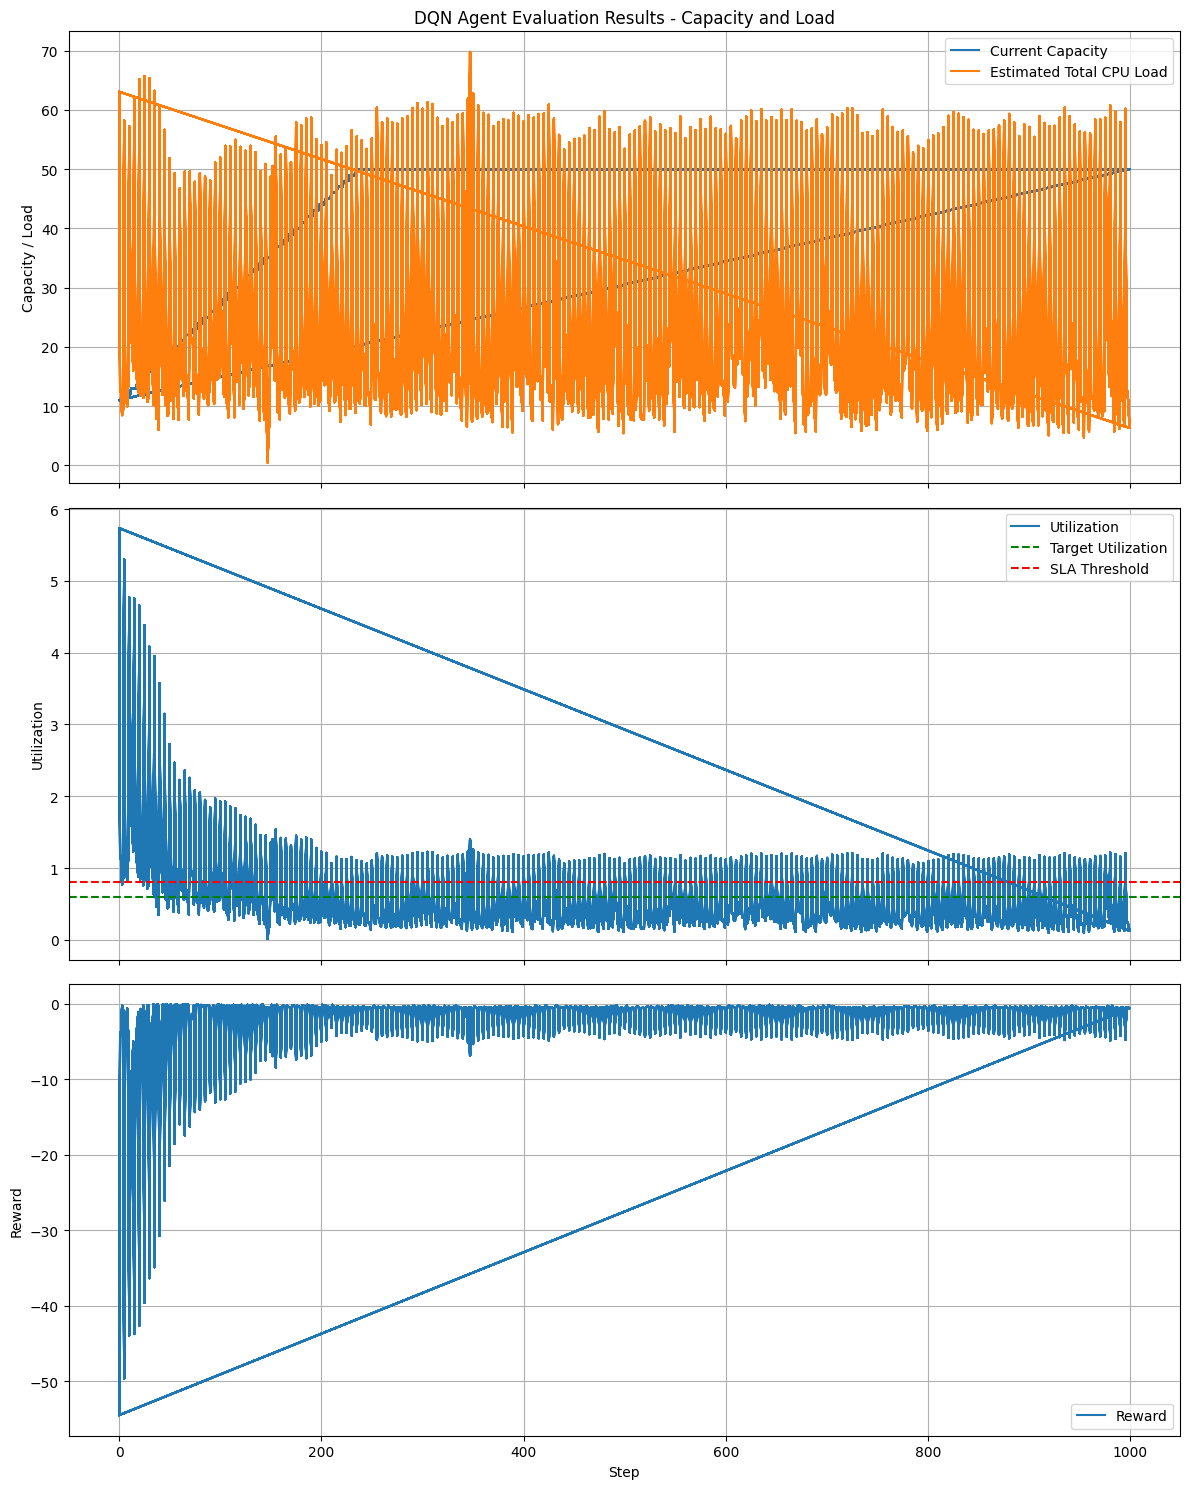

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import pandas as pd

# Define the device to use (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- QNetwork Definition
class QNetwork(nn.Module):
    def __init__(self, observation_space_shape, action_space_size, hidden_size=64):
        super(QNetwork, self).__init__()
        input_features = observation_space_shape[0]
        self.fc1 = nn.Linear(input_features, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_space_size)

    def forward(self, state):
        x = self.relu(self.fc1(state))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

# --- ReplayBuffer Definition
class ReplayBuffer:
    def __init__(self, buffer_size, batch_size):
        self.memory = deque(maxlen=buffer_size)
        self.batch_size = batch_size
        self.experience = (None, None, None, None, None)
        self.seed = random.seed(0)

    def add(self, state, action, reward, next_state, done):
        e = (state, action, reward, next_state, done)
        self.memory.append(e)

    def sample(self):
        experiences = random.sample(self.memory, k=self.batch_size)
        states = torch.from_numpy(np.vstack([e[0] for e in experiences if e is not None])).float().to(device)
        actions = torch.from_numpy(np.vstack([e[1] for e in experiences if e is not None])).long().to(device)
        rewards = torch.from_numpy(np.vstack([e[2] for e in experiences if e is not None])).float().to(device)
        next_states = torch.from_numpy(np.vstack([e[3] for e in experiences if e is not None])).float().to(device)
        dones = torch.from_numpy(np.vstack([e[4] for e in experiences if e is not None]).astype(np.uint8)).float().to(device)
        return (states, actions, rewards, next_states, dones)

    def __len__(self):
        return len(self.memory)

# --- DQNAgent Definition
class DQNAgent:
    def __init__(self, observation_space_shape, action_space_size, seed, buffer_size=int(1e5), batch_size=64, gamma=0.99, lr=5e-4, tau=1e-3, update_every=4):
        self.observation_space_shape = observation_space_shape
        self.action_space_size = action_space_size
        self.seed = random.seed(seed)
        self.gamma = gamma
        self.tau = tau
        self.update_every = update_every
        self.qnetwork_local = QNetwork(observation_space_shape, action_space_size).to(device)
        self.qnetwork_target = QNetwork(observation_space_shape, action_space_size).to(device)
        self.optimizer = optim.Adam(self.qnetwork_local.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_size, batch_size)
        self.t_step = 0

    def step(self, state, action, reward, next_state, done):
        self.memory.add(state, action, reward, next_state, done)
        self.t_step = (self.t_step + 1) % self.update_every
        if self.t_step == 0:
            if len(self.memory) > self.memory.batch_size:
                experiences = self.memory.sample()
                self.learn(experiences, self.gamma)

    def select_action(self, state, eps=0.):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        self.qnetwork_local.eval()
        with torch.no_grad():
            action_values = self.qnetwork_local(state)
        self.qnetwork_local.train()
        if random.random() > eps:
            return np.argmax(action_values.cpu().data.numpy())
        else:
            return random.choice(np.arange(self.action_space_size))

    def learn(self, experiences, gamma):
        states, actions, rewards, next_states, dones = experiences
        Q_targets_next = self.qnetwork_target(next_states).detach().max(1)[0].unsqueeze(1)
        Q_targets = rewards + (gamma * Q_targets_next * (1 - dones))
        Q_expecteds = self.qnetwork_local(states).gather(1, actions)
        loss = nn.MSELoss()(Q_expecteds, Q_targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.soft_update(self.qnetwork_local, self.qnetwork_target, self.tau)

    def soft_update(self, local_model, target_model, tau):
        for target_param, local_param in zip(target_model.parameters(), local_model.parameters()):
            target_param.data.copy_(tau*local_param.data + (1.0-tau)*target_param.data)


def train_agent(agent, env, num_episodes, max_steps_per_episode, epsilon_start, epsilon_end, epsilon_decay):
    scores = []
    epsilon = epsilon_start

    for i_episode in range(1, num_episodes + 1):
        state, info = env.reset()
        score = 0
        done = False
        truncated = False

        for t in range(max_steps_per_episode):
            action = agent.select_action(state, epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            agent.step(state, action, reward, next_state, terminated or truncated)
            state = next_state
            score += reward

            if terminated or truncated:
                break

        scores.append(score)
        epsilon = max(epsilon_end, epsilon_decay * epsilon)

        if i_episode % 10 == 0:
            print(f'Episode {i_episode}\tAverage Score: {np.mean(scores[-10:]):.2f}')

    print("Training finished.")
    return scores

def evaluate_agent(agent, env, num_evaluation_episodes, max_steps_per_evaluation_episode):
    eval_scores = []
    evaluation_results = []

    for i_episode in range(1, num_evaluation_episodes + 1):
        state, info = env.reset()
        score = 0
        episode_results = []

        for t in range(max_steps_per_evaluation_episode):
            action = agent.select_action(state, eps=0.)
            next_state, reward, terminated, truncated, info = env.step(action)

            episode_results.append({
                'step': t,
                'action': action,
                'reward': reward,
                'current_capacity': info['current_capacity'],
                'utilization': info['utilization'],
                'estimated_total_cpu_load': info['estimated_total_cpu_load'],
                'cost_penalty': info['reward_components'].get('cost_penalty', np.nan),
                'sla_penalty': info['reward_components'].get('sla_penalty', np.nan),
                'util_deviation_penalty': info['reward_components'].get('util_deviation_penalty', np.nan)
            })

            state = next_state
            score += reward

            if terminated or truncated:
                break

        eval_scores.append(score)
        evaluation_results.extend(episode_results)

        print(f'Evaluation Episode {i_episode}\tScore: {score:.2f}')

    print(f'\nAverage Evaluation Score over {num_evaluation_episodes} episodes: {np.mean(eval_scores):.2f}')

    evaluation_results_df = pd.DataFrame(evaluation_results)
    evaluation_results_df.set_index('step', inplace=True)

    return eval_scores, evaluation_results_df

# 1. Initialize the AutoScalingEnv environment for the DQN agent
env_dqn = AutoScalingEnv(df_usage)

# 2. Instantiate the DQNAgent
agent_dqn = DQNAgent(
    observation_space_shape=env_dqn.observation_space.shape,
    action_space_size=env_dqn.action_space.n,
    seed=0
)

# 3. Define the training hyperparameters for the DQN agent
num_episodes_dqn = 500
max_steps_per_episode_dqn = 1000
epsilon_start_dqn = 1.0
epsilon_end_dqn = 0.01
epsilon_decay_dqn = 0.995

# 4. Call the train_agent function
dqn_training_scores = train_agent(
    agent_dqn,
    env_dqn,
    num_episodes_dqn,
    max_steps_per_episode_dqn,
    epsilon_start_dqn,
    epsilon_end_dqn,
    epsilon_decay_dqn
)

print("DQN Training Scores:", dqn_training_scores[:5]) # Display first 5 scores for brevity

# 5. Define the evaluation hyperparameters for the DQN agent
num_evaluation_episodes_dqn = 10
max_steps_per_evaluation_episode_dqn = 1000

# 6. Call the evaluate_agent function
dqn_eval_scores, evaluation_results_df_dqn = evaluate_agent(
    agent_dqn,
    env_dqn,
    num_evaluation_episodes_dqn,
    max_steps_per_evaluation_episode_dqn
)

# 7. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15), sharex=True)

# 8. Plot Current Capacity and Estimated Total CPU Load
axes[0].plot(evaluation_results_df_dqn.index, evaluation_results_df_dqn['current_capacity'], label='Current Capacity')
axes[0].plot(evaluation_results_df_dqn.index, evaluation_results_df_dqn['estimated_total_cpu_load'], label='Estimated Total CPU Load')
axes[0].set_ylabel('Capacity / Load')
axes[0].set_title('DQN Agent Evaluation Results - Capacity and Load')
axes[0].legend()
axes[0].grid(True)

# 9. Plot Utilization and Target Utilization
axes[1].plot(evaluation_results_df_dqn.index, evaluation_results_df_dqn['utilization'], label='Utilization')
axes[1].axhline(y=env_dqn.target_utilization, color='g', linestyle='--', label='Target Utilization')
axes[1].axhline(y=env_dqn.sla_threshold, color='r', linestyle='--', label='SLA Threshold')
axes[1].set_ylabel('Utilization')
axes[1].legend()
axes[1].grid(True)

# 10. Plot Reward
axes[2].plot(evaluation_results_df_dqn.index, evaluation_results_df_dqn['reward'], label='Reward')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Reward')
axes[2].legend()
axes[2].grid(True)

# 11. Adjust layout and display plots
plt.tight_layout()
plt.show()